# Optical Character Recognition (image to character)

In [8]:
import cv2
import numpy as np
import pytesseract
from PIL import Image
import requests
import pdfplumber
import pandas as pd
import re
import json
import matplotlib.pyplot as plt
print("All imports successful")

Matplotlib is building the font cache; this may take a moment.


All imports successful


In [5]:
import os #access files in OS

In [4]:
print("sample.jpg found:", os.path.exists("sample.jpg"))

sample.jpg found: True


In [7]:
img = cv2.imread("sample.jpg")

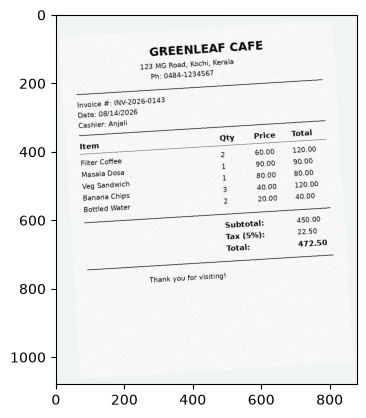

In [9]:
plt.imshow(img)

In [10]:
def preprocess_image(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Denoise
    denoised = cv2.fastNlMeansDenoising(gray, h=30)
    # Adaptive thresholding handles uneven lighting better than a single global threshold
    thresh = cv2.adaptiveThreshold(
        denoised, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 31, 11
    )
    return thresh
processed = preprocess_image("sample.jpg")
cv2.imwrite("processed.jpg", processed)
print("Saved processed.jpg")

Saved processed.jpg


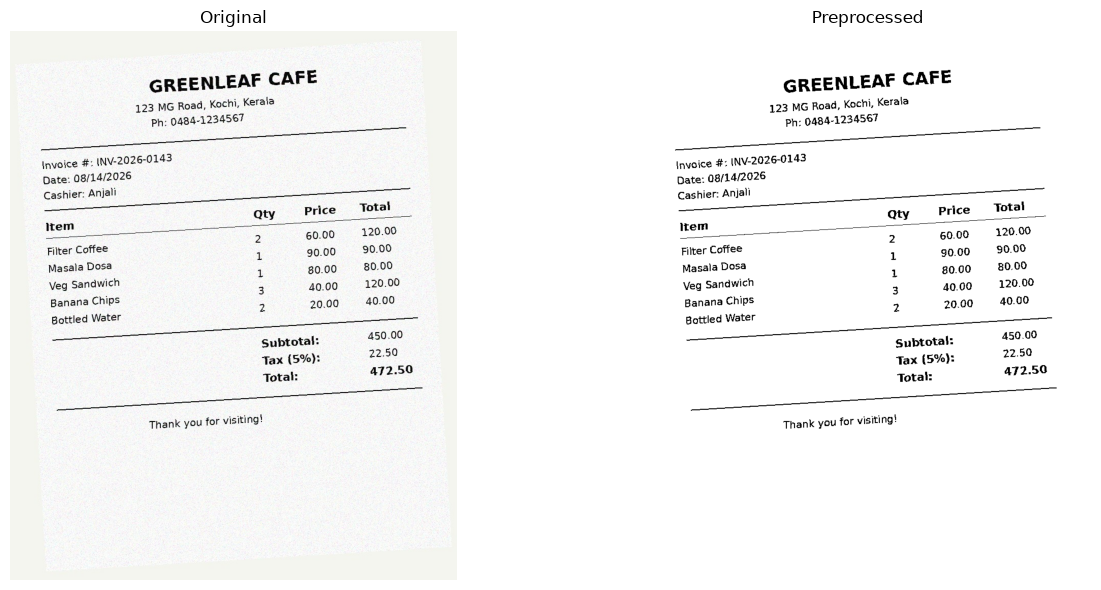

In [11]:
# Side-by-side comparison (great for showing students the "why")
import matplotlib.pyplot as plt
original = cv2.cvtColor(cv2.imread("sample.jpg"), cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(original)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(processed, cmap="gray")
axes[1].set_title("Preprocessed")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [12]:
def ocr_space_image(filepath, api_key='helloworld'):
    with open(filepath, 'rb') as f:
        response = requests.post(
            'https://api.ocr.space/parse/image',
            files={'file': f},
            data={
                'apikey': api_key,
                'language': 'eng',
                'OCREngine': 2,      # engine 2 = better accuracy
                'isTable': True,     # preserves table layout using tabs
                'scale': True
            }
        )
    result = response.json()
    return result['ParsedResults'][0]['ParsedText']
text = ocr_space_image("sample.jpg")
print(text)

GREENLEAF CAFE	
123 MG Road, Kochi, Kerala	
Ph: 0484-1234567	
Invoice #: INV-2026-0143	
Date: 08/14/2026	
Cashier: Anjali	
Total	
Qty	Price	
Item	120.00	
2	60.00	
Filter Coffee	1	90.00	90.00	
Masala Dosa	1	80.00	80.00	
Veg Sandwich	40.00	120.00	
Banana Chips	20.00	40.00	
Bottled Water	
450.00	
Subtotai:	
Tax (5%):	22.50	
Total:	472.50	
Thank you for visiting!	



In [13]:
with pdfplumber.open("document.pdf") as pdf:
    for i, page in enumerate(pdf.pages):
        text = page.extract_text()
        print (text)

Quarterly Sales Report - Q2 2026
This report summarizes regional sales performance for Q2 2026. All figures are in INR (thousands).
Prepared by the Analytics Team, Blackbox Learning.
Regional Breakdown
Region Q1 Sales Q2 Sales Growth %
Kerala 1,240 1,510 21.8%
Tamil Nadu 980 1,150 17.3%
Karnataka 1,600 1,720 7.5%
Telangana 870 990 13.8%
Invoice #: INV-2026-0143
Date: 08/14/2026
Total: $1,249.00
Kerala led growth this quarter, driven by increased demand in the Kochi and Thiruvananthapuram
markets.


In [ ]:
# to extract table
with pdfplumber.open("document.pdf") as pdf:
    page = pdf.pages[0]
    table = page.extract_table()
    df = pd.DataFrame(table[1:],columns=table[0])

In [15]:
def parse_table_text(ocr_text):
    rows = [line.split('\t') for line in ocr_text.strip().split('\n') if line.strip()]
    df = pd.DataFrame(rows[1:], columns=rows[0])
    return df

In [16]:
print(df)

       Region Q1 Sales Q2 Sales Growth %
0      Kerala    1,240    1,510    21.8%
1  Tamil Nadu      980    1,150    17.3%
2   Karnataka    1,600    1,720     7.5%
3   Telangana      870      990    13.8%
